In [1]:
import os
import json
import ipywidgets
import matplotlib.pyplot as plt
import numpy as np

In [2]:
RESULTS_BASE_DIR = "../results"

## Load Results

In [3]:
results_files = [f for f in os.listdir(RESULTS_BASE_DIR) if os.path.isdir(os.path.join(RESULTS_BASE_DIR, f))]
final_results = None

def display_results(file):
    global final_results
    filepath = os.path.join(RESULTS_BASE_DIR, file, file + ".json")
    with open(filepath, 'r') as f:
        final_results = json.load(f)

ipywidgets.interact(display_results, file=results_files);

interactive(children=(Dropdown(description='file', options=('2026-05-09_openai',), value='2026-05-09_openai'),…

In [4]:
# Treating history as part of the model identity
CHAT_MODEL_NAMES = ["GPT4.1", "GPT5.4", "Gemma4_2B", "DeepSeek_V4_Flash"]
CHAT_MODEL_NAMES = [f"{name}_with_history" for name in CHAT_MODEL_NAMES] + CHAT_MODEL_NAMES

def parse_model(cfg_name):
    # Reverse to match more-specific (history) variants first
    for model_name in reversed(CHAT_MODEL_NAMES):
        if model_name in cfg_name:
            return model_name
    return "Unknown"

In [5]:
if not final_results:
    raise ValueError("No experiment data found in final_results to plot.")

## Plot Results

### Per Configuration

Bar plot with one bar per configuration.

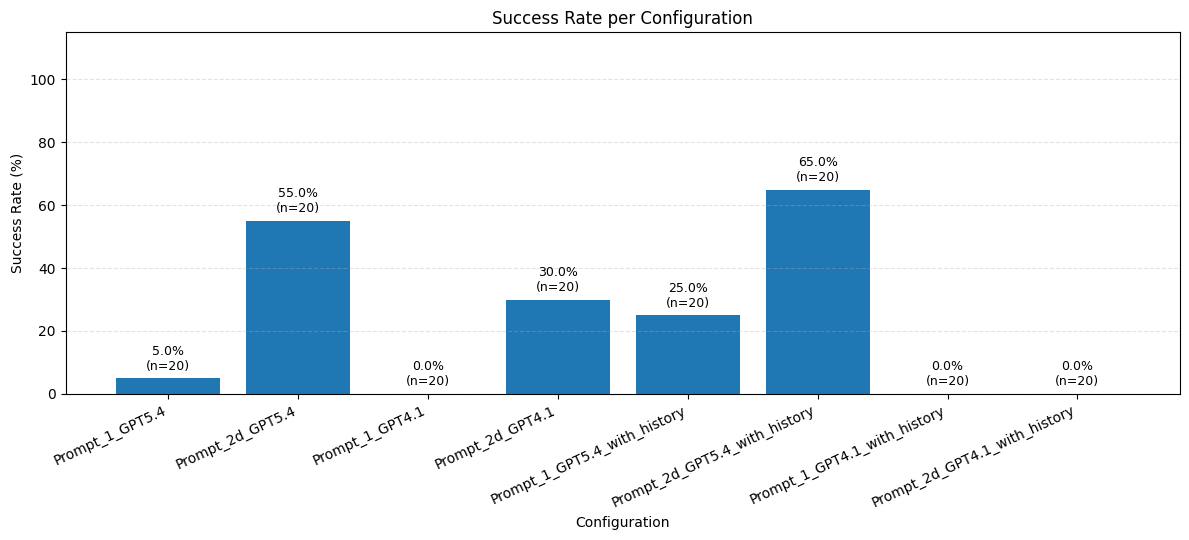

In [6]:
#config_names = sorted(final_results.keys())
config_names = final_results.keys()
success_rates = []
run_counts = []

for cfg in config_names:
    runs = final_results.get(cfg, [])
    successes = [int(run.get("success", 0)) for run in runs]
    rate = 100 * np.mean(successes) if successes else np.nan
    success_rates.append(rate)
    run_counts.append(len(successes))

fig, ax = plt.subplots(figsize=(12, 5.5))
bars = ax.bar(config_names, success_rates)

for bar, rate, n_runs in zip(bars, success_rates, run_counts):
    if np.isnan(rate):
        continue
    ax.annotate(
        f"{rate:.1f}%\n(n={n_runs})",
        xy=(bar.get_x() + bar.get_width() / 2, rate),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_title("Success Rate per Configuration")
ax.set_xlabel("Configuration")
ax.set_ylabel("Success Rate (%)")
ax.set_ylim(0, 115)
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### Per Model (aggregate)

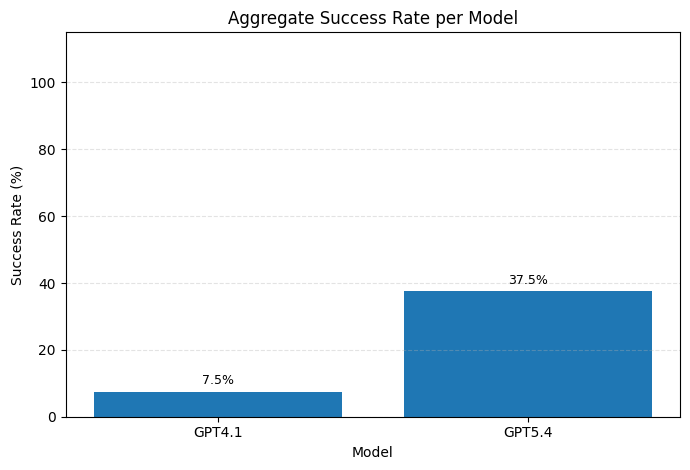

In [7]:
# Gather successes for aggregate metrics
success_by_model = {}

for cfg_name, runs in final_results.items():
    model = parse_model(cfg_name)
    for run in runs:
        env = run["env"]
        success = int(run["success"])
        success_by_model.setdefault(model, []).append(success)

# Aggregate success rate per model
model_labels = sorted(success_by_model.keys())
model_rates = [100 * np.mean(success_by_model[m]) for m in model_labels]

fig, ax = plt.subplots(figsize=(7, 4.8))
bars = ax.bar(model_labels, model_rates)
for b, rate in zip(bars, model_rates):
    ax.annotate(f"{rate:.1f}%",
                xy=(b.get_x() + b.get_width() / 2, rate),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center", va="bottom", fontsize=9)

ax.set_title("Aggregate Success Rate per Model")
ax.set_xlabel("Model")
ax.set_ylabel("Success Rate (%)")
ax.set_ylim(0, 115)
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

### Per Model × Environment

Grouped bar plot: for each model, one bar per environment.

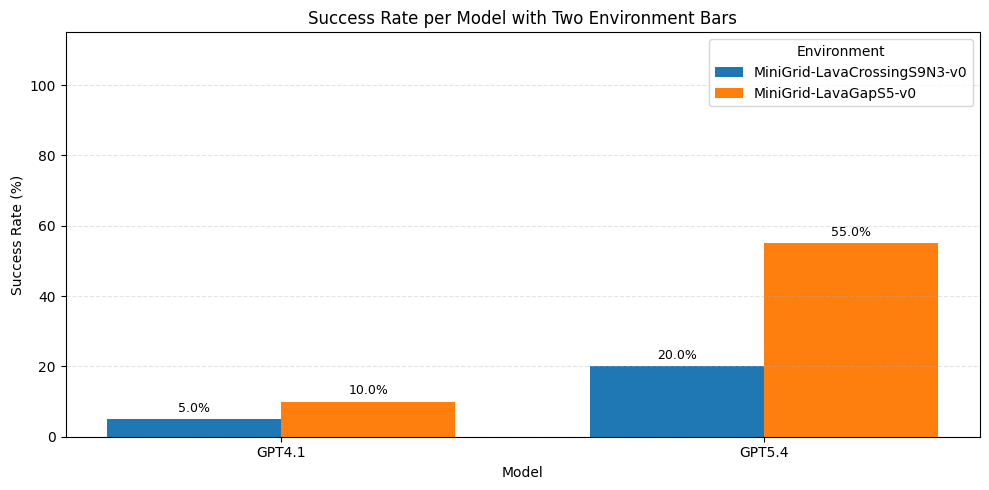

In [8]:
# Collect all successes by (model, environment), combining runs from all prompts
success_by_model_env = {}
for cfg_name, runs in final_results.items():
    model = parse_model(cfg_name)
    for run in runs:
        env = run["env"]
        success_by_model_env.setdefault((model, env), []).append(int(run["success"]))

if not success_by_model_env:
    raise ValueError("No experiment data found in final_results to plot.")

models = sorted({k[0] for k in success_by_model_env.keys()})
envs = sorted({k[1] for k in success_by_model_env.keys()})

if len(envs) != 2:
    raise ValueError(f"Expected exactly 2 environments, found {len(envs)}: {envs}")

# Build rates so each model has exactly two bars (one for each environment)
rates_by_env = {env: [] for env in envs}
for model in models:
    for env in envs:
        vals = success_by_model_env.get((model, env), [])
        rate = 100 * np.mean(vals) if vals else np.nan
        rates_by_env[env].append(rate)

x = np.arange(len(models))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(10, 5))
offsets = [-bar_width / 2, bar_width / 2]

for env, offset in zip(envs, offsets):
    bars = ax.bar(x + offset, rates_by_env[env], width=bar_width, label=env)
    for b in bars:
        h = b.get_height()
        if not np.isnan(h):
            ax.annotate(f"{h:.1f}%",
                        xy=(b.get_x() + b.get_width() / 2, h),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha="center", va="bottom", fontsize=9)

ax.set_title("Success Rate per Model with Two Environment Bars")
ax.set_xlabel("Model")
ax.set_ylabel("Success Rate (%)")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 115)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(title="Environment")
plt.tight_layout()
plt.show()

### Per Environment (aggregate)

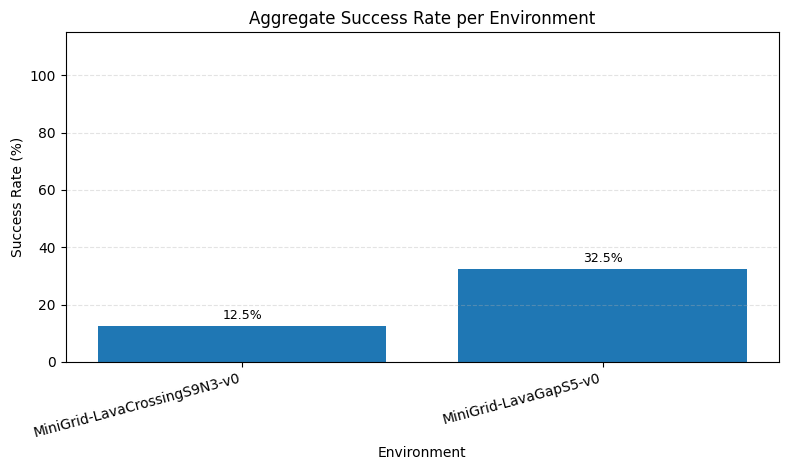

In [9]:
# Gather successes for aggregate metrics
success_by_env = {}

for cfg_name, runs in final_results.items():
    model = parse_model(cfg_name)
    for run in runs:
        env = run["env"]
        success = int(run["success"])
        success_by_env.setdefault(env, []).append(success)

# Aggregate success rate per environment
env_labels = sorted(success_by_env.keys())
env_rates = [100 * np.mean(success_by_env[e]) for e in env_labels]

fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.bar(env_labels, env_rates)
for b, rate in zip(bars, env_rates):
    ax.annotate(f"{rate:.1f}%",
                xy=(b.get_x() + b.get_width() / 2, rate),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center", va="bottom", fontsize=9)

ax.set_title("Aggregate Success Rate per Environment")
ax.set_xlabel("Environment")
ax.set_ylabel("Success Rate (%)")
ax.set_ylim(0, 115)
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()